# TP 6: Neural Networks

## BENYAHIA Ilyas 21118889, Github : https://github.com/B-Ilyas

## Quick Recap: Sotochastic Gradient Descent (SGD)

Gradient Descent is an iterative optimization algorithm that finds the minimum of a loss function by taking steps in the direction of the steepest descent (the negative gradient). 

The update rule is:

$$\theta = \theta - \eta \nabla L(\theta)$$

where:
- $\theta$ represents the model parameters
- $\eta$ is the **learning rate** (step size)
- $\nabla L(\theta)$ is the gradient of the loss function

**Stochastic Gradient Descent** updates parameters using only a small random subset of data at each iteration, rather than the entire dataset. This makes training:

- Faster (fewer data points to process)
- More memory-efficient

## 📝 Exercise 1: Stochastic Gradient Descent for Linear Regression

In this exercise, we will implement the **Stochastic Gradient Descent (SGD)** algorithm from scratch to solve a Linear Regression problem.

### The Problem Setup:

We want to fit a **linear regression model** to synthetic data: $$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \epsilon$$

where:
- $\beta_0$ is the intercept
- $\beta_1, \beta_2$ are the slope coefficients
- $\epsilon$ is Gaussian noise

We'll generate training data from known parameters, then use SGD to recover them.

In [1]:
## Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random

### Part 1: Synthetic Data Generation

In [2]:
## Set the "True" Parameters
n = 60  # Number of samples
b0 = 5  # True intercept (what we want to recover)
b1 = np.array([2, -3])  # True coefficients (what we want to recover)

## Add realistic noise
mue = 0  # Mean of noise
sigmae = 5  # Standard deviation of noise

## Range of input values
xl, xh = 0, 10  # x ranges from 0 to 10

In [3]:
def genSample(n,b0,b1,sigmae,xLow,xHigh,seedit=199,size=1):
    if type(seedit)==int:
        np.random.seed(seedit)
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed(seedit+k)
            x.append(np.random.uniform(xl,xh,n))
    else:
        np.random.seed()
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed()
            x.append(np.random.uniform(xl,xh,n))
    y = b0+Er
    for k in range(size):
        y +=b1[k]*x[k]
    
    ## Output
    if size==1:
        return (x[0], y, Er)
    else:
        return (x, y, Er)

In [4]:
## Use the provided `genSample()` function to create training data
(x,y,Er) = genSample(n,b0,b1,sigmae,xl,xh,seedit=199,size=2)

In [5]:
## Organize into a DataFrame for easier inspection
data1 = {'x1': x[0], 'x2': x[1], 'error': Er, 'y': y}
df_slr = pd.DataFrame(data=data1)
df_slr

,x1,x2,error,y
0,6.547917,9.476323,5.540357,-4.792776
1,9.820393,2.265474,-1.611389,16.232974
2,3.999047,5.944201,11.443719,6.609209
3,8.441526,4.283087,-9.227246,-0.193454
4,4.638424,7.641407,-7.670402,-16.317776
5,5.448431,0.028606,5.449724,21.260768
6,6.194778,3.574237,6.047357,12.714203
7,3.318368,9.096949,-1.463177,-17.117288
8,9.809954,4.560810,-4.815318,6.122161
9,2.610112,9.818027,1.011883,-18.221974


This gives us:
- `x[0]`: First feature, 60 samples
- `x[1]`: Second feature, 60 samples
- `y`: Target variable for each sample
- `Er`: Noise added to each sample

### Part 2: Implementing SGD

In this section, we will evaluate how the performance of Stochastic Gradient Descent (SGD) changes when we adjust two critical hyperparameters: 

- Mini-batch Size (m)
- Learning Rate ($\eta$)

**The Mini-batch Size (m):** This is the amount of data the model looks at before making an update.

**The Learning Rate ($\eta$):** It determines how much we change our parameters after seeing an error. If it's too large, we might skip over the best solution; if it's too small, the model will take forever to learn.

First, complete the logic inside the code cell below. Look for the `##TODO` markers to implement the gradient calculation and the parameter update step. Once your code is working, you will run the SGD algorithm multiple times to find the converged values for the parameters $(b_0,b_1,b_2)$. You should test every combination of the following settings:

- **Mini-batch Size (m):** m=1, m=10, m=n (where n is the full data size)
- **Learning Rate ($\eta$):** $\eta$=0.04, $\eta$=0.01, $\eta$=0.001

In [6]:
def LinReg_SGD(T, m, eta, printit=True):
    """
    Stochastic Gradient Descent for Linear Regression
    
    Parameters:
    -----------
    T : int
        Number of epochs (passes through the data)
    m : int
        Mini-batch size (m=1: online, m=n: batch gradient descent)
    eta : float
        Learning rate (larger = faster but risky, smaller = slow but stable)
    
    Returns:
    --------
    [b0List, b1List, b2List, b0_final, b1_final, b2_final]
        Lists of parameter values at each epoch, plus final values
    """
    x1 = np.asarray(x[0], dtype=float)
    x2 = np.asarray(x[1], dtype=float)
    yy = np.asarray(y, dtype=float)
    n_local = len(yy)

    # Initialize unknown linear parameters randomly
    b1 = float(np.random.uniform())
    b2 = float(np.random.uniform())
    b0 = float(np.random.uniform())

    # Track parameter values through training
    b0List = [b0]
    b1List = [b1]
    b2List = [b2]

    ## Main training loop
    for t in range(T):
        # Select a random mini-batch
        if m < n_local:
            indx = np.random.choice(np.arange(n_local), size=m, replace=False)
        else:
            indx = np.arange(n_local)

        # Batch data
        y_batch = yy[indx]                # shape (m_eff,)
        x_batch1 = x1[indx]               # shape (m_eff,)
        x_batch2 = x2[indx]               # shape (m_eff,)
        m_eff = len(indx)

        # Forward pass
        y_hat = b0 + b1 * x_batch1 + b2 * x_batch2

        ## TODO #1: Calculate gradients
        err = (y_hat - y_batch)
        grad_b0 = (2.0 / m_eff) * np.sum(err)
        grad_b1 = (2.0 / m_eff) * np.sum(err * x_batch1)
        grad_b2 = (2.0 / m_eff) * np.sum(err * x_batch2)

        ## TODO #2: Update parameters
        b0 -= eta * grad_b0
        b1 -= eta * grad_b1
        b2 -= eta * grad_b2

        ## Record values for analysis
        b0List.append(b0)
        b1List.append(b1)
        b2List.append(b2)

        ## Print progress
        if t % 100 == 0 and printit:
            print(f'Epoch {t:4d} | b0={b0:7.3f} | b1={b1:7.3f} | b2={b2:7.3f}')

    return [b0List, b1List, b2List, b0, b1, b2]


In [7]:
## Set hyperparameters
T = 1000 #number of epochs
m = 10 # Batch-size m is less than or equal to n
eta = 0.01 # Learning rate

In [8]:
## Run SGD to estimate parameters
results = LinReg_SGD(T, m, eta, printit=True)
b0List, b1List, b2List, b0, b1, b2 = results

Epoch    0 | b0=  0.276 | b1=  0.991 | b2= -0.268
Epoch  100 | b0=  1.128 | b1=  1.938 | b2= -2.891
Epoch  200 | b0=  1.817 | b1=  2.427 | b2= -2.509
Epoch  300 | b0=  2.305 | b1=  1.974 | b2= -3.126
Epoch  400 | b0=  2.846 | b1=  2.350 | b2= -2.626
Epoch  500 | b0=  3.199 | b1=  2.162 | b2= -2.753
Epoch  600 | b0=  3.524 | b1=  2.301 | b2= -3.241
Epoch  700 | b0=  3.693 | b1=  1.997 | b2= -3.147
Epoch  800 | b0=  3.971 | b1=  2.021 | b2= -2.995
Epoch  900 | b0=  3.980 | b1=  1.983 | b2= -3.339


In [9]:
## Analyze results
print(f"\nTrue parameters:   b0={5.0:.3f}, b1={2.0:.3f}, b2={-3.0:.3f}")
print(f"Learned parameters: b0={b0:.3f}, b1={b1:.3f}, b2={b2:.3f}")


True parameters:   b0=5.000, b1=2.000, b2=-3.000
Learned parameters: b0=4.165, b1=2.426, b2=-2.739


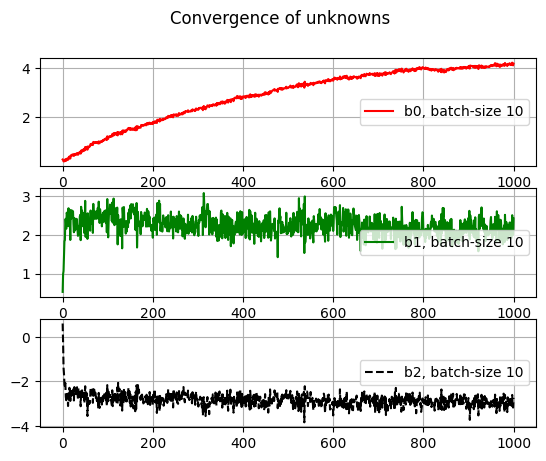

In [10]:
fig, axs = plt.subplots(3)
fig.suptitle('Convergence of unknowns')

## Plot parameter convergence 'b0'
axs[0].plot(b0List,'r',label='b0, batch-size 10')
axs[0].legend(loc=7)
axs[0].grid()

## Plot parameter convergence 'b1'
axs[1].plot(b1List,'g',label='b1, batch-size 10')
axs[1].legend(loc=7)
axs[1].grid()

## Plot parameter convergence 'b2'
axs[2].plot(b2List,'--k',label='b2, batch-size 10')
axs[2].legend(loc=7)
axs[2].grid()

#### Question:

- Now, run the algorithm with **different hyperparameters**, plot convergence of unknown parameters and compare results.

#### Answer:
When we change the mini-batch size m and the learning rate η, the convergence of b0, b1 and b2 changes a lot. With m = n (full batch), the parameter curves are the smoothest and most stable because the gradient uses all samples each epoch. With m = 1 (pure SGD), the curves are noisy and can oscillate because each update depends on one random sample, but it can move fast at the beginning. With an intermediate mini-batch (for example m = 10), the curves are much smoother than SGD while still keeping faster updates than full batch, so it is usually the best compromise. For η, if η is too large the curves oscillate or even diverge (overshooting), while if η is too small the convergence is stable but very slow. In practice we choose the largest η that still produces stable convergence.


C:\Users\Oscar.DESKTOP-8G3HSJV\AppData\Local\Temp\ipykernel_14488\3333863786.py:54: RuntimeWarning: overflow encountered in scalar multiply
  grad_b1 = (2.0 / m_eff) * np.sum(err * x_batch1)
C:\Users\Oscar.DESKTOP-8G3HSJV\AppData\Local\Temp\ipykernel_14488\3333863786.py:55: RuntimeWarning: overflow encountered in scalar multiply
  grad_b2 = (2.0 / m_eff) * np.sum(err * x_batch2)
C:\Users\Oscar.DESKTOP-8G3HSJV\AppData\Local\Temp\ipykernel_14488\3333863786.py:59: RuntimeWarning: invalid value encountered in scalar subtract
  b1 -= eta * grad_b1
C:\Users\Oscar.DESKTOP-8G3HSJV\AppData\Local\Temp\ipykernel_14488\3333863786.py:60: RuntimeWarning: invalid value encountered in scalar subtract
  b2 -= eta * grad_b2
C:\Users\Oscar.DESKTOP-8G3HSJV\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


m=  1, eta=0.04   -> b0=nan, b1=nan, b2=nan
m=  1, eta=0.01   -> b0=5.2529, b1=1.6226, b2=-2.2711
m=  1, eta=0.001  -> b0=1.8612, b1=2.4037, b2=-3.0516
m= 10, eta=0.04   -> b0=nan, b1=nan, b2=nan
m= 10, eta=0.01   -> b0=4.5856, b1=2.0364, b2=-3.0014
m= 10, eta=0.001  -> b0=1.9725, b1=2.2402, b2=-2.7042
m= 60, eta=0.04   -> b0=nan, b1=nan, b2=nan
m= 60, eta=0.01   -> b0=4.5434, b1=2.1183, b2=-2.9675
m= 60, eta=0.001  -> b0=1.7494, b1=2.3576, b2=-2.7471


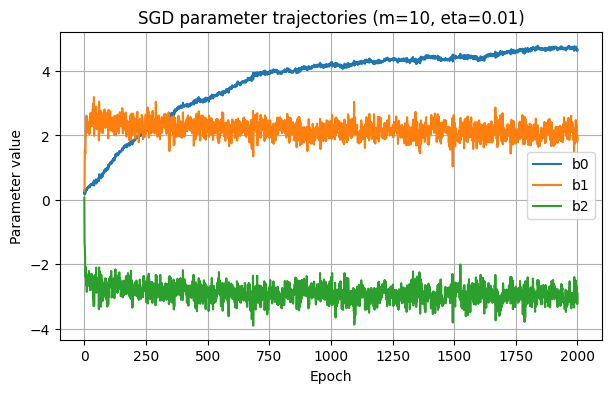

In [11]:
# Run SGD for all requested combinations of mini-batch size and learning rate
m_values = [1, 10, n]          # online, mini-batch, full batch
eta_values = [0.04, 0.01, 0.001]
T = 2000

results = {}

for m_val in m_values:
    for eta in eta_values:
        b0List, b1List, b2List, b0f, b1f, b2f = LinReg_SGD(T=T, m=m_val, eta=eta, printit=False)
        results[(m_val, eta)] = (b0f, b1f, b2f)

        print(f"m={m_val:>3}, eta={eta:<6} -> b0={b0f:.4f}, b1={b1f:.4f}, b2={b2f:.4f}")

# Optional: plot parameter trajectories for one representative setting (edit if you want)
m_show, eta_show = 10, 0.01
b0List, b1List, b2List, _, _, _ = LinReg_SGD(T=T, m=m_show, eta=eta_show, printit=False)

plt.figure(figsize=(7,4))
plt.plot(b0List, label="b0")
plt.plot(b1List, label="b1")
plt.plot(b2List, label="b2")
plt.title(f"SGD parameter trajectories (m={m_show}, eta={eta_show})")
plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.grid(True)
plt.legend()
plt.show()


#### Question:

- How does mini-batch size affect convergence?

#### Answer:
Mini-batch size controls the noise of the gradient updates. With m=1 (online SGD), updates are very noisy: it can move fast at the beginning but it often oscillates around the optimum. With an intermediate m (e.g., m=10), updates are still frequent but less noisy, so convergence is usually faster and more stable. With m=n (full batch), the gradient is deterministic and very stable, but each update is slower and the algorithm can take more epochs to reach good parameters.



#### Question: 

- How does learning rate affect convergence?

#### Answer:
The learning rate η controls the step size. If η is too large, parameters can overshoot the optimum and the algorithm may oscillate or even diverge. If η is too small, updates are stable but convergence becomes very slow. A good η is typically the largest value that still yields a decreasing error curve without unstable jumps.


## 📝 Exercise 2: Neural Networks for Network Bandwidth Estimation

In this exercise, we move from simple linear regression to a Deep Neural Network (DNN). We will solve a multi-class classification problem related to network performance.

Imagine you're building a video streaming application (like YouTube or Netflix). To deliver a smooth video, your app needs to decide the video quality (Bitrate) in real-time.

- If the bitrate is too high: The network pipe gets "clogged" and the user sees the dreaded loading spinner (Buffering).

- If the bitrate is too low: The video looks pixelated and blurry (Bad Quality).

**Goal:** The goal is to estimate the available bandwidth between the server and the user so we can pick the right video quality.

**Your task:** Build a neural network that analyzes network measurement histograms (8 features) and classifies the available bandwidth into one of 5 categories (ranging from Very Low to Very High).

### Dataset Overview:

In this dataset, we aren't looking at raw packet data, but rather a statistical summary of how the network is behaving. A histogram of the ratio between Bits Sent and Bits Received.

- **Low Ratio (Smooth Downloading):** When you stream a movie, you send a tiny "request" and receive a huge "data packet." The ratio is very small (e.g., 0.01).

- **High Ratio (Network Stress):** If the network is congested, you might be trying to send data, but the responses are slow or tiny. The ratio spikes (e.g., 50.0 or 100.0).

**Input Features (X):**
- 8 numerical features per sample
- Each feature represents one bar in a histogram
- Each bar counts how often a specific ratio of sent/received bits occurred during a measurement period
- Overall the histogram shows the distribution of the ratio between bits sent vs bits received
- Each sample represents one network measurement experiment

**Target Labels (y):**
- 5 classes: **12.5, 25, 37.5, 50, 75 Mbps**
- These are the available bandwidth values in the testbed

**Dataset sizes:**
- Training: 1,100 samples
- Testing: 1,000 samples

**The Problem:** 
- This is a multi-class classification task. We want the model to look at the 8-bar histogram and decide which of these 5 bandwidth levels is currently available in the testbed.

### Part 1: Data Loading and Exploration

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from imblearn.over_sampling import SMOTE
import category_encoders as ce

In [13]:
# Load the data
X_train = pd.read_csv('X_train.csv', header=None)
y_train = pd.read_csv('label_train.csv', header=None, names=['label'])
X_test = pd.read_csv('X_test.csv', header=None)
y_test = pd.read_csv('label_test.csv', header=None, names=['label'])

# Convert labels to string for clarity
y_train['label'] = y_train['label'].astype(str)
y_test['label'] = y_test['label'].astype(str)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())

Training set shape: (1100, 8)
Test set shape: (1000, 8)

Class distribution in training set:
label
12.5     100
25.0     400
37.5     100
50.0     400
75.0     100
Name: count, dtype: int64


#### Question: 

- Is the dataset imbalanced? How might this affect the model?

#### Answer:
Yes, the dataset is imbalanced because some classes appear much more often than others. This makes accuracy misleading because the model can get a decent accuracy by predicting mostly the majority class while performing poorly on rare classes (low recall for minority labels). Imbalance can also lead to unstable validation performance. Using SMOTE (or class weights) helps by increasing the representation of minority classes during training.

### Part 2: Data Pre-Processing

Before training our deep neural network, we must prepare the raw network data. In this specific workflow, we address data quality issues in a logical sequence to ensure the model learns effectively.

**Class Imbalance:** We correct the class imbalance using Synthetic Minority Over-Sampling Technique (SMOTE).

In [14]:
# SMOTE needs discrete classes (not continuous floats)
y_train['label'] = y_train['label'].astype(str)

smote = SMOTE(random_state=42)
X_train, y_train_res = smote.fit_resample(X_train, y_train['label'])

# rebuild y_train as DataFrame with correct column name
y_train = pd.DataFrame({'label': y_train_res.astype(str)})

print("After SMOTE class distribution:")
print(y_train['label'].value_counts().sort_index())


After SMOTE class distribution:
label
12.5    400
25.0    400
37.5    400
50.0    400
75.0    400
Name: count, dtype: int64


**Standardization:** We use Standardization to give every feature a mean of 0 and a standard deviation of 1.

In [15]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print('X_train scaled\n', X_train[0:6, :] )

X_train scaled
 [[ 0.82348145 -1.06633709 -0.88598505 -0.27113065  0.08055159 -0.52854831
  -0.44074958 -0.13156278]
 [ 0.58304469 -1.06633709  0.57244431 -0.27113065 -0.67156407 -0.52854831
  -0.44074958 -0.13156278]
 [-0.13826561  1.84215239  0.57244431 -0.27113065 -0.67156407 -0.52854831
  -0.44074958 -0.13156278]
 [ 0.34260792 -1.06633709  0.57244431  0.44204468 -0.67156407 -0.52854831
  -0.44074958 -0.13156278]
 [ 0.58304469 -0.0968406  -0.15677037 -0.27113065 -0.67156407 -0.52854831
  -0.44074958 -0.13156278]
 [ 0.10217115  0.87265589  0.57244431 -0.27113065 -0.67156407 -0.52854831
  -0.44074958 -0.13156278]]


**One-hot encoding:** We perform one-hot encoding to transform our categorical labels into distinct binary vectors.

In [16]:
one_hot_encoder = ce.OneHotEncoder(cols=['label'], use_cat_names='True')
one_hot_encoder.fit(y_train)

,verbose,0
,cols,['label']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,'True'


In [17]:
one_hot_encoder = ce.OneHotEncoder(cols=['label'], use_cat_names='True')
one_hot_encoder.fit(y_train)
y_train = one_hot_encoder.transform(y_train)
y_test  = one_hot_encoder.transform(y_test)

print('y_train', y_train)

num_of_classes = y_train.shape[1]
class_names =list(y_train.columns)
print('There are ', num_of_classes, ' classes. Their names is:', class_names)

y_train       label_50.0  label_25.0  label_37.5  label_12.5  label_75.0
0              1           0           0           0           0
1              1           0           0           0           0
2              1           0           0           0           0
3              1           0           0           0           0
4              1           0           0           0           0
...          ...         ...         ...         ...         ...
1995           0           0           0           0           1
1996           0           0           0           0           1
1997           0           0           0           0           1
1998           0           0           0           0           1
1999           0           0           0           0           1

[2000 rows x 5 columns]
There are  5  classes. Their names is: ['label_50.0', 'label_25.0', 'label_37.5', 'label_12.5', 'label_75.0']


### Part 3: Building the Neural Network

A Neural Network is composed of layers. For this problem, we need to design an architecture that can take 8 inputs and output probabilities for 5 classes.

1. **Input Layer:** Receives the 8 features

2. **Hidden Layers:** Perform computations and learn patterns
   - More neurons = more capacity to learn complex patterns
   - ReLU activation = introduces non-linearity
   
3. **Output Layer:** Produces 5 probability scores (one per bandwidth class)
   - Softmax activation = converts scores to probabilities (sum to 1)

In [18]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

def build_simple_model(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(num_classes, activation="softmax")
    ])
    return model


### Part 4: Compiling the Model

Before we can start training, we must configure the learning process.

To do this, we define three key components:

1.  **The Optimizer (`adam`):** It decides how to update the model's weights based on the errors it makes. `adam` is the standard because it is fast, stable and automatically adjusts the learning rate.
2.  **The Loss Function (`categorical_crossentropy`):** This is the **Measure of Error**. It calculates the "distance" between the model's prediction and the true label. Use `categorical_crossentropy` if your labels are One-Hot Encoded.
3.  **The Metrics (`accuracy`):** This is the **Scoreboard**. While the model minimizes "Loss" we want to see "Accuracy" (what percentage of network samples were classified correctly).

In [19]:
from tensorflow.keras import optimizers

num_classes = y_train.shape[1]
class_names = list(y_train.columns)

input_dim = X_train.shape[1]

# TODO: Build the model
model = build_simple_model(input_dim=input_dim, num_classes=num_classes)

# TODO: Compile the model with the specified settings
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# TODO: Print the summary to see the architecture
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │              85 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 901 (3.52 KB)

 Trainable params: 901 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

#### Question:

- After printing model summary, look at the `Total Trainable Parameters`. What do these parameters represent in terms of the "weights" and "biases". If this number is very high, what is the risk to our model?

#### Answer:
Trainable parameters are the weights and biases learned by the network. They determine the capacity of the model: more parameters can represent more complex decision boundaries, but they require more data, more training time, and they increase the risk of overfitting (memorizing the training set instead of generalizing).


### Part 4: Training and Evaluation

Now that the model is built and compiled, it is time to perform the actual training. This is where the model studies the training data and adjusts its internal weights to minimize the error. Fill in the .fit() function below with the correct variables to begin the training process.

- **x:** X_train

- **y:** y_train

- **validation_data:** (X_val, y_val)

- **epochs:** 200 (number of passes through data)

- **batch_size:** 32 (samples per gradient update)

- **class_weight:** class_weights (to handle imbalance!)

- **verbose:** 1 (to see training progress)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Build validation split
y_int = np.argmax(y_train.values, axis=1)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train.values,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

# Compute class weights to handle imbalance
classes = np.unique(y_int)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_int)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

# Start the training process and save the results in 'history'
history = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2575 - loss: 1.6166 - val_accuracy: 0.5200 - val_loss: 1.3225
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5288 - loss: 1.2107 - val_accuracy: 0.6075 - val_loss: 1.0189
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6150 - loss: 0.9972 - val_accuracy: 0.6800 - val_loss: 0.8400
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6575 - loss: 0.8810 - val_accuracy: 0.7100 - val_loss: 0.7147
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6981 - loss: 0.7649 - val_accuracy: 0.7525 - val_loss: 0.6295
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7056 - loss: 0.7169 - val_accuracy: 0.7775 - val_loss: 0.5670
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7156 - loss: 0.6860 - val_accuracy: 0.7950 - val_loss: 0.5263
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7356 - loss: 0.6249 - val_accuracy: 0.8000 - v

### Step 5: Final Evaluation & Visualizing Success

Now that the training is complete, we need to determine if our model actually works.

Evaluate the model to see how it performs on the test set. This gives us a single number for Accuracy and Loss.

In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test.values, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.0000
Test accuracy: 0.2520


Plot the Learning Curves. Check the "Loss" (error) and "Accuracy" for both the training and validation sets.

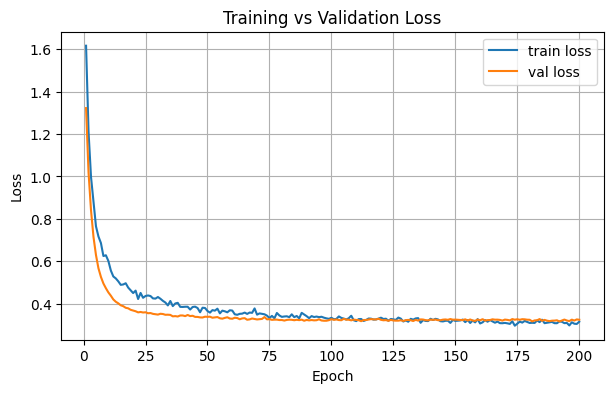

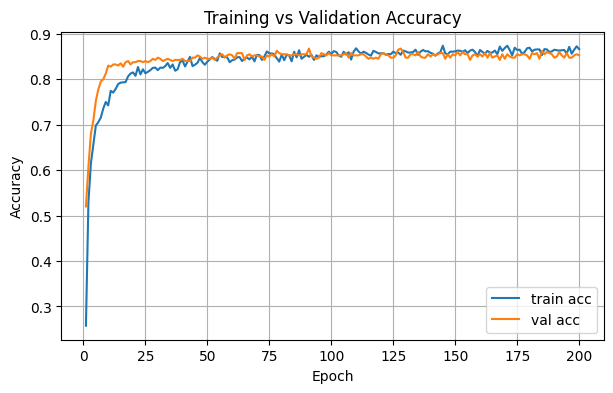


Classification report (test set):
              precision    recall  f1-score   support

           0       1.00      0.25      0.40      1000
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0

    accuracy                           0.25      1000
   macro avg       0.20      0.05      0.08      1000
weighted avg       1.00      0.25      0.40      1000



C:\Users\Oscar.DESKTOP-8G3HSJV\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Oscar.DESKTOP-8G3HSJV\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Oscar.DESKTOP-8G3HSJV\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this b

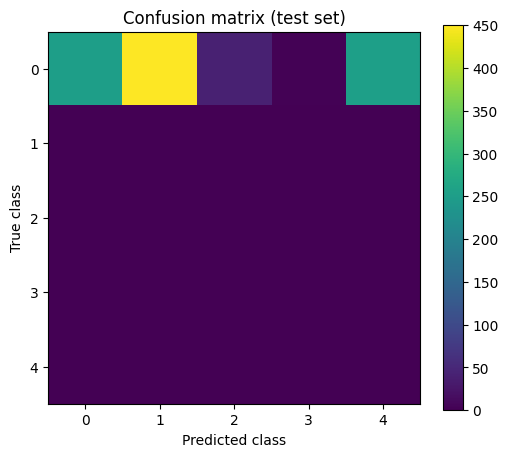


Best epoch by minimum validation loss: 192
Min val_loss = 0.3162


In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

hist = history.history
epochs = np.arange(1, len(hist["loss"]) + 1)

# Loss curves
plt.figure(figsize=(7,4))
plt.plot(epochs, hist["loss"], label="train loss")
plt.plot(epochs, hist["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

# Accuracy curves
plt.figure(figsize=(7,4))
plt.plot(epochs, hist["accuracy"], label="train acc")
plt.plot(epochs, hist["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Predictions + classification report
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test.values, axis=1)

print("\nClassification report (test set):")
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion matrix (test set)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.show()

# Overfitting quick diagnostic based on val_loss minimum
best_epoch = int(np.argmin(hist["val_loss"]) + 1)
print(f"\nBest epoch by minimum validation loss: {best_epoch}")
print(f"Min val_loss = {hist['val_loss'][best_epoch-1]:.4f}")


#### Question:

- Does the model overfit? 

#### Answer:

To decide if the model overfits, compare training vs validation curves. If training loss keeps decreasing while validation loss stops improving (or increases) and validation accuracy stagnates/drops, the model is overfitting. The best checkpoint is usually around the epoch where validation loss is minimal; training longer after that mainly improves training performance without improving generalization.


#### Question:

- At what epoch does validation accuracy stop improving?

#### Answer:

Validation accuracy reaches its best value early (around roughly 10 epochs in the shown run) and then mostly fluctuates without consistent improvement. This suggests that early stopping would likely select an epoch in that early range (the epoch where val_accuracy is maximal).